# Dataset Link: https://www.kaggle.com/datasets/kishoresabbavarapu/breast-cancer-image-dataset

In [31]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [32]:
import shutil

source_dir = r"C:\Users\Abdullah\__torch\Datasets\Ultrasound Breast Cancer Images"


image_dir = os.path.join(source_dir, "images")
mask_dir = os.path.join(source_dir, "masks")


os.makedirs(image_dir, exist_ok=True)
os.makedirs(mask_dir, exist_ok=True)


for filename in os.listdir(source_dir):
    file_path = os.path.join(source_dir, filename)

    if os.path.isdir(file_path):
        continue

    if "_mask" in filename:
        shutil.move(file_path, os.path.join(mask_dir, filename))
    else:
        shutil.move(file_path, os.path.join(image_dir, filename))

print("Done organizing dataset")

Done organizing dataset


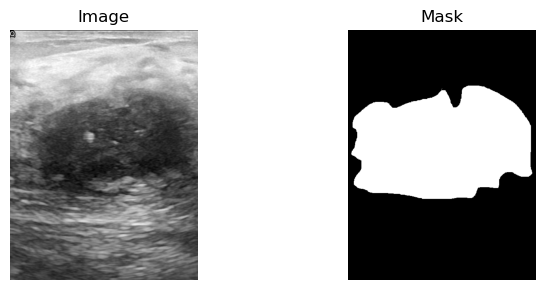

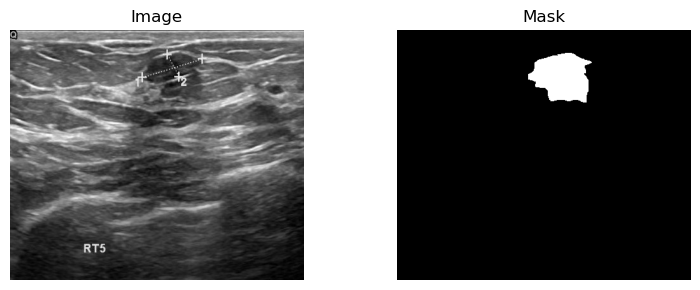

In [ ]:
images = os.listdir(image_dir)

images.sort()

num_samples = 5

for i in range(num_samples):
    img_name = images[i]

    # corresponding mask name
    mask_name = img_name.replace(".png", "_mask.png")

    img_path = os.path.join(image_dir, img_name)
    mask_path = os.path.join(mask_dir, mask_name)

    # read image
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # read mask (grayscale)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # plot
    plt.figure(figsize=(8, 3))

    plt.subplot(1, 2, 1)
    plt.title("Image")
    plt.imshow(image)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Mask")
    plt.imshow(mask, cmap="gray")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [30]:
random_img_dir = os.listdir(image_dir)[1]
print(random_img_dir)

random_mask_dir = os.listdir(mask_dir)[1]

img = cv2.imread(os.path.join(image_dir, random_img_dir))
mask1 = cv2.imread(os.path.join(mask_dir, random_mask_dir))
print(f'Shape of the Image {img.shape} || Shape of the Mask {mask1.shape}')

malignant(10).png
Shape of the Image (393, 462, 3) || Shape of the Mask (393, 462, 3)


In [27]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    

    A.Resize(256, 256),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=25, p=0.5),

    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=20,
        p=0.5
    ),

    A.RandomBrightnessContrast(p=0.3),


    A.GaussNoise(p=0.2),

    A.Normalize(mean=(0.0, 0.0, 0.0),
                std=(1.0, 1.0, 1.0)),

    ToTensorV2()
])

ModuleNotFoundError: No module named 'albumentations'

In [ ]:
val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.0, 0.0, 0.0),
                std=(1.0, 1.0, 1.0)),
    ToTensorV2()
])

In [29]:
!pip install albumentations opencv-python

  Using cached albumentations-2.0.8-py3-none-any.whl.metadata (43 kB)
  Using cached albucore-0.0.24-py3-none-any.whl.metadata (5.3 kB)
  Using cached eval_type_backport-0.3.1-py3-none-any.whl.metadata (2.4 kB)
  Using cached opencv_python_headless-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached numpy-2.0.2-cp39-cp39-win_amd64.whl.metadata (59 kB)
Using cached albumentations-2.0.8-py3-none-any.whl (369 kB)
Using cached albucore-0.0.24-py3-none-any.whl (15 kB)
Using cached opencv_python_headless-4.13.0.92-cp37-abi3-win_amd64.whl (40.1 MB)
Using cached numpy-2.0.2-cp39-cp39-win_amd64.whl (15.9 MB)
Using cached eval_type_backport-0.3.1-py3-none-any.whl (6.1 kB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:


ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'c:\\users\\abdullah\\anaconda3\\envs\\cvpr\\lib\\site-packages\\numpy-1.26.4-cp39-cp39-win_amd64.whl'



In [4]:
class BreastDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = os.listdir(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name.replace(".png", "_mask.png"))

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # convert mask to binary
        mask = (mask > 0).astype("float32")

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"].unsqueeze(0)  

        return image, mask

In [5]:
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(3, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.bridge = DoubleConv(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(self.pool1(d1))
        d3 = self.down3(self.pool2(d2))

        b = self.bridge(self.pool3(d3))

        u3 = self.up3(b)
        u3 = torch.cat([u3, d3], dim=1)
        u3 = self.conv3(u3)

        u2 = self.up2(u3)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.conv1(u1)

        return torch.sigmoid(self.out(u1))

In [6]:
def dice_loss(pred, target, smooth=1):
    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    return 1 - (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

dataset = BreastDataset(image_dir, mask_dir)
loader = DataLoader(dataset, batch_size= 32, shuffle=True)

model = UNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [8]:
save_dir = "unet_model"
os.makedirs(save_dir, exist_ok=True)

best_loss = float("inf")
thres = 5
counter = 0

epochs = 30

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)

        preds = model(imgs)
        loss = dice_loss(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)

    print(f"Epoch [{epoch+1}/{epochs}] | Dice Loss: {avg_loss:.4f}")

    if avg_loss < best_loss:
        print("Model Dice Loss Improved... Saving the new model")

        best_loss = avg_loss
        counter = 0  

        model_path = os.path.join(save_dir, "best_model.pth")

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "loss": best_loss
        }, model_path)

    else:
        counter += 1

    if counter >= thres:
        print("Early Stopped...")
        break

Epoch [1/30] | Dice Loss: 0.7722
Model Dice Loss Improved... Saving the new model
Epoch [2/30] | Dice Loss: 0.7697
Model Dice Loss Improved... Saving the new model
Epoch [3/30] | Dice Loss: 0.7720
Epoch [4/30] | Dice Loss: 0.7662
Model Dice Loss Improved... Saving the new model
Epoch [5/30] | Dice Loss: 0.7438
Model Dice Loss Improved... Saving the new model
Epoch [6/30] | Dice Loss: 0.7130
Model Dice Loss Improved... Saving the new model
Epoch [7/30] | Dice Loss: 0.7068
Model Dice Loss Improved... Saving the new model
Epoch [8/30] | Dice Loss: 0.7002
Model Dice Loss Improved... Saving the new model
Epoch [9/30] | Dice Loss: 0.6943
Model Dice Loss Improved... Saving the new model
Epoch [10/30] | Dice Loss: 0.6812
Model Dice Loss Improved... Saving the new model
Epoch [11/30] | Dice Loss: 0.6849
Epoch [12/30] | Dice Loss: 0.6836
Epoch [13/30] | Dice Loss: 0.6854
Epoch [14/30] | Dice Loss: 0.7081
Epoch [15/30] | Dice Loss: 0.6883
Early Stopped...


In [9]:
def visualize(model, dataset, num_samples=3):
    model.eval()

    for i in range(num_samples):
        img, mask = dataset[i]
        img = img.unsqueeze(0).to(device)

        with torch.no_grad():
            pred = model(img)

        pred = pred.squeeze().cpu().numpy()
        mask = mask.squeeze().numpy()
        img = img.squeeze().cpu().permute(1,2,0).numpy()

        plt.figure(figsize=(10,3))

        plt.subplot(1,3,1)
        plt.title("Image")
        plt.imshow(img)

        plt.subplot(1,3,2)
        plt.title("Ground Truth")
        plt.imshow(mask, cmap='gray')

        plt.subplot(1,3,3)
        plt.title("Prediction")
        plt.imshow(pred > 0.5, cmap='gray')

        plt.show()

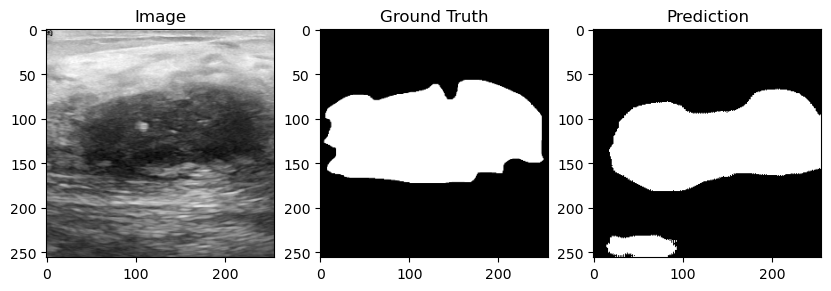

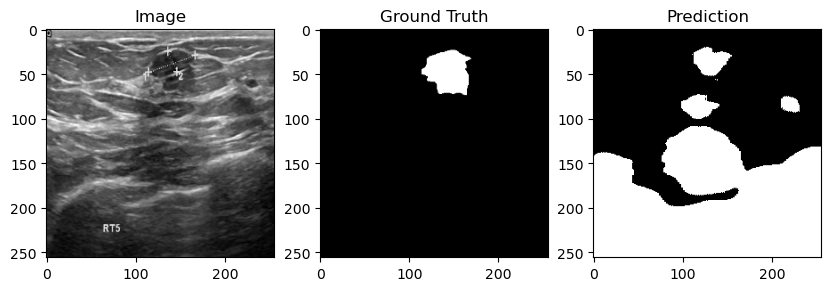

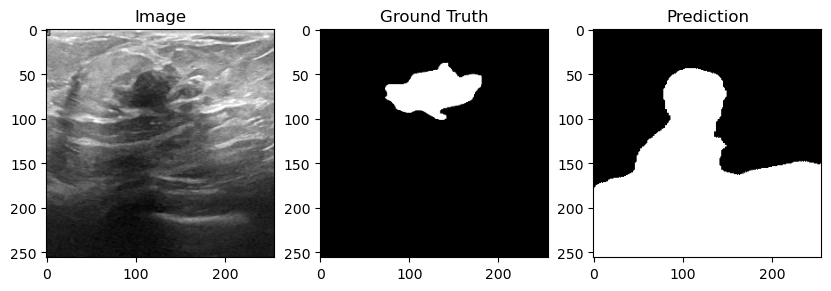

In [10]:
visualize(model, dataset)